# 01 · P300 speller: from flashes to ERPs

**ROBT613 · Brain–Computer Interfaces** | Teaching session + independent lab

## Goal
Load a real P300 speller recording, inspect target imbalance, visualize event-related activity and extract temporal features.

**Data:** BNCI2014-009, subject 1, three sessions; MOABB → MNE

Run cells from top to bottom in a fresh CPU runtime. No previous notebook state is required.

## The question for today

A student sees a positive bump around 300 ms and calls it a working speller. Your task is to slow down that conclusion: identify what was flashed, which flashes were attended, how the EEG was aligned, and what averaging hides. By the end, you will have a defensible feature matrix, not yet a character decoder.

### By the end you should be able to

- Explain target versus non-target labels in a row/column attention task.
- Derive why class averaging improves random-noise visibility but not single-trial reliability.
- Construct temporal-window features and keep trial/session identifiers aligned.
- Interpret an ERP plot without selecting features on held-out evaluation data.

**How to work:** predict each result before running it, execute one cell at a time, and write a short interpretation. The worked examples use small controlled arrays; the later walkthrough uses the dataset stated above. End-of-lesson exercises contain editable workspaces. A pending exercise message is expected until you complete its function.

## Setup
The first cell installs the tested core versions in Colab. Downloads are cached in `mne_data/`; a new Colab runtime loses that cache. A failed download is an error, never silently replaced by synthetic data.

In [1]:
# Colab: install before importing numerical libraries. Restart if pip requests it.
import sys, subprocess, os
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'mne==1.13.2', 'moabb==1.7.2'])
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from scipy import signal
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.model_selection import (GroupKFold, cross_validate, GridSearchCV)
SEED = 613
rng = np.random.default_rng(SEED)
DATA_ROOT = Path(os.environ.get('BCI_DATA', './mne_data')).resolve()
DATA_ROOT.mkdir(parents=True, exist_ok=True)
os.environ['MNE_DATA'] = str(DATA_ROOT)
mne.set_log_level('WARNING')
plt.rcParams.update({'figure.figsize': (9, 4), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
import importlib.metadata as metadata
print({p: metadata.version(p) for p in ['mne','moabb','numpy','scipy','scikit-learn']})
print('Dataset cache:', DATA_ROOT)

{'mne': '1.13.2', 'moabb': '1.7.2', 'numpy': '2.1.3', 'scipy': '1.15.3', 'scikit-learn': '1.6.1'}
Dataset cache: <dataset-cache>


### Begin with the experiment, not the classifier

Imagine a 6×6 grid. A person attends one symbol while rows and columns intensify. A flash is a target if its group contains that symbol. In a complete 12-group repetition, two groups are targets. The target rate is therefore $2/12=1/6$ for that idealized schedule. This explains class imbalance before looking at any machine-learning output. It does not tell us the complete timing or sequence metadata of a particular file; those must come from its experimental record.

The label belongs to a **flash**, while the communication goal belongs to a **character**. Several flash decisions may be needed for one character. Confusing those units leads to invalid speed estimates and leakage when flashes from the same intended symbol appear on both sides of a split. Our real-data analysis holds out sessions to preserve a meaningful boundary.

### What an ERP actually estimates

Write a single epoch as $X_i(t)=s_{y_i}(t)+\epsilon_i(t)$. The class average estimates $s_k(t)$ if nuisance variation averages away. In reality, latency jitter, overlapping responses and nonstationarity violate this simple model. Averaging epochs with variable peak latency can broaden the response and reduce its apparent height. A small average does not prove that every individual trial lacks a response.

For a mean-amplitude feature, a window is part of the hypothesis. A 0.25–0.40 s average measures voltage over an interval, whereas a peak feature searches for an extreme. Searching over many times can pick noise, especially with few trials. We begin with means because their definition is stable and easy to audit. The windows used below are fixed teaching choices; improving them requires training-only validation.

### Read the loader as a processing contract

`P300(fmin=0.5, fmax=20, tmin=0, tmax=0.8, resample=128)` is not merely a file download. It requests filtering, epoch extraction and resampling. Applying another filter without recognizing this would change the pipeline twice. `return_epochs=True` retains MNE metadata and gives volt-valued EEG. Always print the returned labels, shapes and metadata. Keep `metadata_p300` alongside the arrays: a shuffled feature table without a correspondingly shuffled session column silently corrupts evaluation.

### Worked example · count target flashes

Construct one idealized repetition for a target at row 2, column 4 (zero-based). This is a small experiment-design model, not a reconstruction of the downloaded recording.

**Before running:** state your prediction and the assumption behind it.

In [2]:
demo_flash_groups=np.arange(12)
demo_target_row,demo_target_column=2,4
demo_target=(demo_flash_groups==demo_target_row)|(demo_flash_groups==6+demo_target_column)
print(pd.DataFrame({'flash_group':demo_flash_groups,'is_target':demo_target}))
print('Target fraction:',demo_target.mean())
print('Always non-target accuracy:',1-demo_target.mean())

    flash_group  is_target
0             0      False
1             1      False
2             2       True
3             3      False
4             4      False
5             5      False
6             6      False
7             7      False
8             8      False
9             9      False
10           10       True
11           11      False
Target fraction: 0.16666666666666666
Always non-target accuracy: 0.8333333333333334


**Read the result.** The easy-looking 83.3% majority accuracy follows from the stimulus schedule. It is not evidence that EEG contains useful predictive information.

**Pause and explain:** point to one computed value that supports this interpretation.

### Worked example · derive window averaging

For samples $[2,4,6]$ µV in a window, the mean is 4 µV. In a batch, compute that operation independently for every trial and channel. The output must lose the time axis and keep the other two.

**Before running:** state your prediction and the assumption behind it.

In [3]:
demo_cube=np.array([[[2.,4.,6.,100.],[1.,3.,5.,100.]],
                    [[0.,2.,4.,100.],[2.,2.,2.,100.]]])*1e-6
demo_times=np.array([.2,.3,.4,.5])
demo_mask=(demo_times>=.2)&(demo_times<.5)
demo_features=demo_cube[:,:,demo_mask].mean(-1)
print('Features in µV:\n',demo_features*1e6)
assert demo_features.shape==(2,2)
assert np.isclose(demo_features[0,0]*1e6,4)

Features in µV:
 [[4. 3.]
 [2. 2.]]


**Read the result.** The large value at the excluded endpoint must not contribute. State whether a window includes its right endpoint; otherwise two adjacent windows may accidentally count a sample twice.

**Pause and explain:** point to one computed value that supports this interpretation.

### Guided experiment · latency jitter changes the average

Generate positive responses with the same amplitude but different latencies. Predict whether averaging preserves peak height. Use the same y-axis for the two conditions.

**Before running:** state your prediction and the assumption behind it.

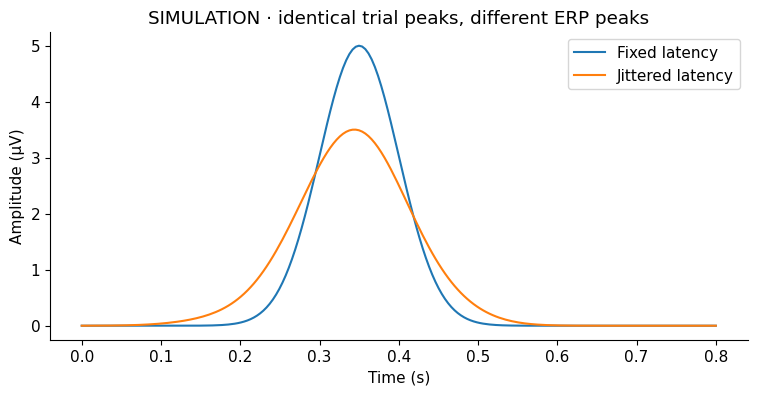

In [4]:
demo_times=np.linspace(0,.8,200)
fixed=np.array([5*np.exp(-.5*((demo_times-.35)/.05)**2) for _ in range(100)])
jittered=np.array([5*np.exp(-.5*((demo_times-center)/.05)**2)
                   for center in rng.normal(.35,.06,100)])
fig,ax=plt.subplots()
ax.plot(demo_times,fixed.mean(0),label='Fixed latency')
ax.plot(demo_times,jittered.mean(0),label='Jittered latency')
ax.set(xlabel='Time (s)',ylabel='Amplitude (µV)',title='SIMULATION · identical trial peaks, different ERP peaks')
ax.legend();plt.show()

**Read the result.** A broader, lower ERP can arise without reducing the amplitude of any single response. This is one reason to inspect single-trial images as well as averages.

**Pause and explain:** point to one computed value that supports this interpretation.

### Guided experiment · compare mean and maximum estimators

With independent zero-mean noise, the window mean is centered near zero but the maximum tends to be positive. This illustrates selection bias in a peak search.

**Before running:** state your prediction and the assumption behind it.

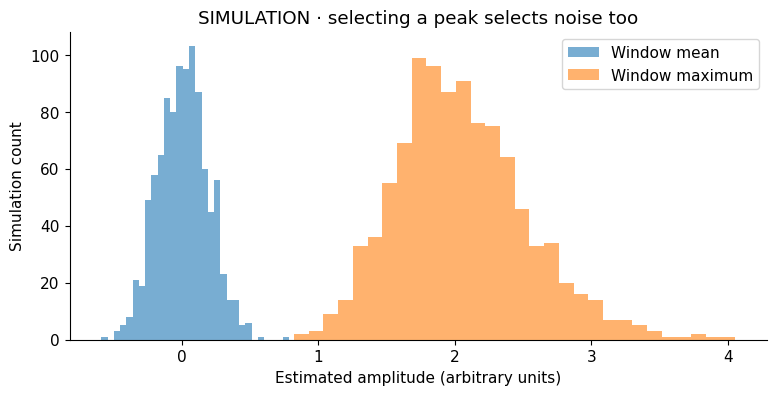

In [5]:
noise_windows=rng.normal(0,1,(1000,30))
fig,ax=plt.subplots()
ax.hist(noise_windows.mean(1),bins=30,alpha=.6,label='Window mean')
ax.hist(noise_windows.max(1),bins=30,alpha=.6,label='Window maximum')
ax.set(xlabel='Estimated amplitude (arbitrary units)',ylabel='Simulation count',title='SIMULATION · selecting a peak selects noise too')
ax.legend();plt.show()

**Read the result.** A positive maximum is expected even with no signal. A feature can be useful for prediction without being an unbiased estimate of ERP amplitude, but that distinction must be explicit.

**Pause and explain:** point to one computed value that supports this interpretation.

## Apply the ideas to the complete pipeline

The next stages use the real recording or the explicitly labeled simulation described in the lesson. Keep preprocessing, feature extraction and evaluation decisions visible. Read each stage’s explanation before running its code.

### Method reference for the pipeline

A row/column speller briefly intensifies groups of symbols. The attended group is a target; other groups are non-targets. A target can evoke a positive deflection several hundred milliseconds later, but latency and amplitude vary and a P300 is not guaranteed on each flash. Attention, fatigue and overlapping responses matter.

An epoch is $X_i(c,\tau)=x_c(t_i+\tau)$. An ERP is $\bar X_k(c,\tau)=N_k^{-1}\sum_{i:y_i=k}X_i(c,\tau)$. Averaging reduces independent zero-mean noise approximately as $1/\sqrt{N_k}$; this does not remove systematic artifacts. A time-window feature is $z_{icw}=|W|^{-1}\sum_{\tau\in W}X_i(c,\tau)$.

We use BNCI2014-009 through MOABB. It is a **P300 speller dataset, not BCI Competition II/III speller data**. MOABB returns MNE epochs and preserves session/run metadata, but its binary paradigm interface does not provide enough character/flash identity for verified text decoding. Notebook 02 separates real target detection from a controlled character-decoding exercise.

We choose a 0.5–20 Hz passband and 0–0.8 s epochs. No pre-stimulus baseline is available in this extraction; do not claim one was applied. Nearby flash epochs overlap: randomly splitting individual flashes risks shared signal and character context across train and test. Hold out entire sessions.

## Load real speller epochs
The loader filters and resamples; it returns EEG in volts. Check class labels rather than assuming numeric codes.

MOABB supplies an MNE Epochs object with labels and trial metadata. The P300 paradigm specifies filtering, epoch limits and resampling in one place. The label conversion explicitly identifies the target class; inspect the printed label counts before proceeding. This dataset is a public speller dataset accessed through MOABB, not a built-in MNE competition archive.

In [6]:
from moabb.datasets import BNCI2014_009
from moabb.paradigms import P300
dataset = BNCI2014_009()
paradigm = P300(fmin=0.5, fmax=20, tmin=0, tmax=0.8, resample=128)
epochs, labels, metadata_p300 = paradigm.get_data(
    dataset=dataset, subjects=[1], return_epochs=True)
y = (np.asarray(labels) == 'Target').astype(int)
X = epochs.get_data(copy=True)  # volts; epochs x channels x samples
session = metadata_p300['session'].astype(str).to_numpy()
assert X.shape[0] == len(y) == len(session)
assert set(np.unique(y)) == {0, 1}
print(pd.crosstab(session, np.asarray(labels)))
print('Shape:', X.shape, 'sampling:', epochs.info['sfreq'], 'Hz')

<local-python-environment>/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:494: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")
<local-python-environment>/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:494: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")
<local-python-environment>/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:494: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")


col_0  NonTarget  Target
row_0                   
0            480      96
1            480      96
2            480      96
Shape: (1728, 16, 103) sampling: 128.0 Hz


### Inspect and interpret

Inspect the session column and the target/non-target counts. Verify that `len(y)`, `len(metadata_p300)` and the number of epochs agree. These three objects must retain the same row ordering throughout analysis.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Inspect the ERP
Plot the nearest available parietal channel. These averages are descriptive; do not choose a classification time window using the held-out session.

We select a parietal sensor by its name and average each class separately. Multiplication by one million changes only the displayed units. The shaded region marks a predeclared response interval, not a region selected because the plotted difference happened to be largest.

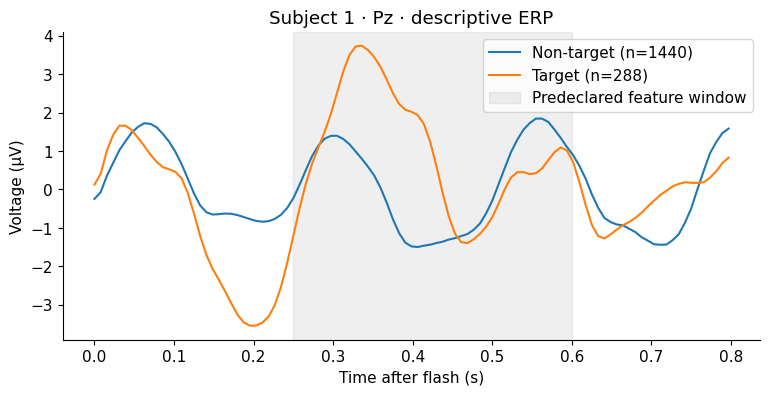

In [7]:
channel = 'Pz' if 'Pz' in epochs.ch_names else epochs.ch_names[-1]
c = epochs.ch_names.index(channel)
fig, ax = plt.subplots()
for label, name in [(0,'Non-target'),(1,'Target')]:
    ax.plot(epochs.times, X[y==label,c].mean(0)*1e6, label=f'{name} (n={(y==label).sum()})')
ax.axvspan(.25,.6,color='gray',alpha=.12,label='Predeclared feature window')
ax.set(xlabel='Time after flash (s)',ylabel='Voltage (µV)',title=f'Subject 1 · {channel} · descriptive ERP')
ax.legend(); plt.show()

### Inspect and interpret

Describe polarity, approximate latency and overlap. A class-average difference motivates a feature but does not establish single-trial accuracy. These all-session plots are descriptive; do not use them to tune the later held-out-session classifier.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Extract interpretable features
Use several predeclared windows so a classifier can combine channels and latencies.

Each window contributes one mean per channel, then concatenation creates a trial × feature table. This compression retains coarse temporal structure while avoiding one independent model weight for every sample. The half-open window masks keep adjacent windows from double-counting boundary samples.

In [8]:
windows = [(0.1,0.25),(0.25,0.4),(0.4,0.6),(0.6,0.8)]
features = np.concatenate([X[:,:, (epochs.times>=a)&(epochs.times<b)].mean(-1)
                           for a,b in windows], axis=1)
assert features.shape == (len(y), len(epochs.ch_names)*len(windows))
print('Features:', features.shape, 'target fraction:', y.mean())
print('Always non-target accuracy:', (y==0).mean(), 'balanced accuracy: 0.5')

Features: (1728, 64) target fraction: 0.16666666666666666
Always non-target accuracy: 0.8333333333333334 balanced accuracy: 0.5


### Inspect and interpret

Calculate the expected number of columns from channels × windows and compare it with the printed shape. Identify which columns correspond to the first time window. A feature name should make both channel and latency recoverable.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Independent practice

Work through the tasks in order. Exercise 1 includes a small implementation check; passing it verifies the stated example, not every possible input. For the investigations, save a labeled figure or table and a short explanation. Use copies of data objects when changing preprocessing, and preserve any held-out evaluation partition.

**Submission:** your completed notebook, the requested outputs, and a brief exit-ticket response. The notebook runs before exercises are completed; “pending” means your work is still required.

### Exercise 1 · Implement a temporal feature

Complete `window_mean` below. Use a half-open interval [start, stop). Preserve the trial and channel axes and reject an empty window with a useful error.

In [9]:
def window_mean(data, times, start, stop):
    # TODO: data is trials × channels × time; return trials × channels.
    return None

In [10]:
answer=window_mean(demo_cube,np.array([.2,.3,.4,.5]),.2,.5)
if answer is not None:
    np.testing.assert_allclose(answer,np.array([[4,3],[2,2]])*1e-6); print('Window checks passed.')
else:
    print('Exercise pending: implement window_mean.')

Exercise pending: implement window_mean.


**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

### Exercise 2 · Audit the real dataset

Create a table of target/non-target counts for every session. Compute target fraction and majority-class accuracy for each session. Explain why the label proportions matter.

In [11]:
# Your investigation: add code here.
# Keep the original data and final test partition intact.

**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

### Exercise 3 · Single trial versus average

Plot five target trials at Pz alongside their average. Use microvolts and a common axis. Describe variability that the average hides.

In [12]:
# Your investigation: add code here.
# Keep the original data and final test partition intact.

**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

### Exercise 4 · Feature comparison

Using calibration sessions only, compare 0.25–0.40 s and 0.40–0.60 s means. Report class distributions rather than choosing the window with the prettiest full-dataset ERP.

In [13]:
# Your investigation: add code here.
# Keep the original data and final test partition intact.

**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

### Exercise 5 · Timing sensitivity

Shift the synthetic response by 100 ms and recompute the fixed-window feature. Explain the implication of an uncorrected stimulus-marker delay.

In [14]:
# Your investigation: add code here.
# Keep the original data and final test partition intact.

**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

### Exercise 6 · Exit ticket

In 150 words, distinguish an ERP contrast, flash detection and character decoding. List the additional metadata needed for the last task.

**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

## Next steps and sources
[Dataset documentation](https://moabb.neurotechx.com/docs/generated/moabb.datasets.BNCI2014_009.html) · [MNE epochs](https://mne.tools/stable/auto_tutorials/epochs/10_epochs_overview.html).

Record package versions, subject/run IDs, preprocessing, split unit, random seed, and all exclusions with your results. Do not interpret a single participant as a population estimate.